##Contents

0.   Learning Objectives
1.   Tutorial Details
2.   Problem Statement Description
3.   Import Packages
4.   Load and Prepare the Dataset
5.   Peform Exploratory Data Analysis (EDA)
6.   Model Building: Training and Testing
7.   Results and Interpretation
8.   Conclusion
9.   Try it yourself excercise
10.  Summary

#0. Learning Objectives

*   Application of **Ridge Kernel Regression** on a custom dataset
*   Handle **Outlier** in the data
*   **Grid Search** for hyperparameter tuning
*   **Polynomial Kernel Regression** example

#1. Tutorial Details

*   **ML Topic(s) Covered**: Kernel Regression
*   Approximate model training time: Less than 5 min.

#2. Problem Statement Description

*   **Objective**: To build a Kernel regression model for learning the underlying trend in the encrypted enemy signal based on the recent interception of about 45 samples.
*   **Data Description**: This data belogns to a secret agent in a foreign land who has recently intercepted an encrypted signal of small duration (about 45 sample in 45 secodns). Your task is to  exploit the available information to understand the trend in the signal (which is helpful in decrypting the signal).
*   Each row represents a time stamp in which the signal was sampled. There are 45 rows in this data.
*   There is only 1 data attribute, viz., the time stamp. The corresponding value is the target variable. Note that time in decimal represents the part of the second the data was intercepting
*   Data URL: https://raw.githubusercontent.com/sachinmotwani20/NPTEL-ML_Datasets/main/InterceptedSignal.csv


# 3. Import Packages

Package versions

*   pandas==1.4.4
*   numpy==1.22.4
*   matplotlib==3.7.1
*   sklearn==1.2.2


In [1]:
# Pandas contains functions data manipulation and analysis
import pandas as pd

#Numpy combines high-level mathematical operating capabilites with large, multi-dimensional arrays and matrices
import numpy as np

# Matplotlib is a data visualization library containing functions for static, animated, and interactive 2D and 3D plots
import matplotlib.pyplot as plt

# Scikit-learn (sklearn) contains functions of machine learning models, evaluation metrics, helper functions and datasets
import sklearn

# 4. Load and Prepare the Dataset

In [2]:
#Import the data from the provided URL and store it as a DataFrame
data = pd.read_csv("https://raw.githubusercontent.com/sachinmotwani20/NPTEL-ML_Datasets/main/InterceptedSignal.csv")
#Print
data.head()

,time-stamp,value
0,-1.000000,0.000000
1,0.681818,0.630206
2,1.363636,0.978619
3,2.045455,0.889449
4,2.727273,0.402567


Here, we have one feature and one target variable placed respectively.

In [3]:
#Print the shape of the data
data.shape

(45, 2)

There are 2 columns and 45 rows in the imported data.

In [4]:
#Check information about the data including information about the rows and columns, number of non-null values per column, datatype of each column  and total memory usage.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   time-stamp  45 non-null     float64
 1   value       44 non-null     float64
dtypes: float64(2)
memory usage: 848.0 bytes




*   All are float values.
*   There is one null value in 'value' column.




Let us find out the index of the null value.

In [5]:
data[data['value'].isnull()].index

Int64Index([25], dtype='int64')

The null value is present at the 25th index of the 'value' column.

In [6]:
#View the 25th row of the dataset
data.iloc[25]

time-stamp    17.045455
value               NaN
Name: 25, dtype: float64

Indeed it is a null value.

Now, we need to make a decision on what to do with this value.

According to the current problem statement, one cannot simply assume any value of the 'value' column based on the time stamp. Therefore, the best suited solution is to drop the row.

In [7]:
#Drop the row with 25th row
df = data.drop([25]).reset_index()
df = df.drop(['index'], axis=1)
df

,time-stamp,value
0,-1.000000,0.000000
1,0.681818,0.630206
2,1.363636,0.978619
3,2.045455,0.889449
4,2.727273,0.402567
5,3.409091,-0.264319
6,4.090909,-0.813018
7,4.772727,-200.000000
8,5.454545,-0.737013
9,6.136364,-0.146295


Notice that the for the first row, the 'time-stamp' is -1, which is not a possible value for time. This means this is a noisy sample which needs to be investigated.

After checking the corresponding value of the target variable, it turns out that this is a starting point of the interception for which the time stamp should be zero. Here, the target variable is also zero.

Thus, we change the value of time-stamp in first row from -1 to 0.

In [8]:
df.iloc[0][0] = 0
df

,time-stamp,value
0,0.000000,0.000000
1,0.681818,0.630206
2,1.363636,0.978619
3,2.045455,0.889449
4,2.727273,0.402567
5,3.409091,-0.264319
6,4.090909,-0.813018
7,4.772727,-200.000000
8,5.454545,-0.737013
9,6.136364,-0.146295


Below, let us separate the feature (independent variable) and the target variable (dependent variable) in the data.

In [9]:
features = df.iloc[:, :-1]
predictions = df.iloc[:, -1] #Last column contains the target variable

In [10]:
#Print a fews rows of independent variables
features.head()

,time-stamp
0,0.000000
1,0.681818
2,1.363636
3,2.045455
4,2.727273


In [11]:
#Print a fews rows of dependent variables
predictions.head()

0    0.000000
1    0.630206
2    0.978619
3    0.889449
4    0.402567
Name: value, dtype: float64

The data is split into feature and prediction. Now, it will be further divided into the training and testing data.

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, predictions, test_size=0.2, random_state=42, shuffle=True)
#20% of the total data is kept as test data

#5.   Peform Exploratory Data Analysis (EDA)

Exploratory data analysis (EDA) is a crucial step in understanding and analyzing any dataset.

Henceforth, all the analysis will be performed on the train dataset only. Assume that we do not possess the test data.

In [13]:
Train_data = pd.concat([X_train, y_train], axis = 'columns') #Join along the columns
Train_data.head()

,time-stamp,value
3,2.045455,0.889449
6,4.090909,-0.813018
27,19.090909,0.239017
31,21.818182,0.172106
19,12.954545,0.378500


In [14]:
#Print summary statistics
Train_data.describe()

,time-stamp,value
count,35.000000,35.000000
mean,14.415584,-5.616773
std,8.984891,33.830094
min,0.000000,-200.000000
25%,7.159091,-0.520639
50%,13.636364,0.026142
75%,21.477273,0.775974
max,30.000000,0.999415


There is a huge gap between the minimum value of the 'value' column and the first quartile (25%). Let us examine the box plot to better understand this abnormality.

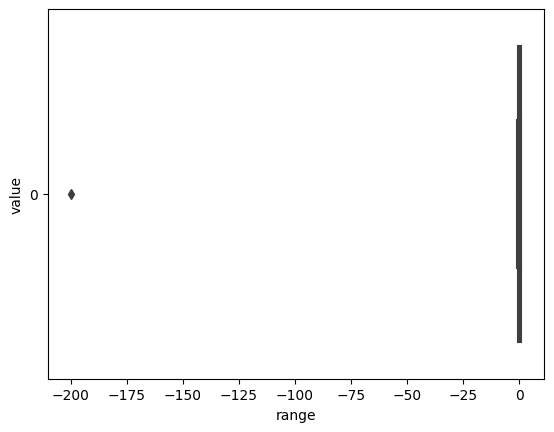

In [15]:
# Seaborn is a data visualization library based on matplotlib
import seaborn as sns

sns.boxplot(data=y_train, orient="h").set(xlabel= 'range', ylabel='value')
plt.show()

There seems to be an outlier point. Let us validate this further. For this, we will use the IQR Rule in which the values lower than the 1.5*IQR below the first quartile and the values higher than the 1.5xIQR above the third quartile represent outliers.
Boxplot uses the 1.5xIQR to plot the outliers.

In [16]:
q1 = np.quantile(y_train.to_numpy(), 0.25) # finding the 1st quartile
q3 = np.quantile(y_train.to_numpy(), 0.75) #finding the 3rd quartile
median = np.median(y_train.to_numpy())

# find the iqr region
iqr =q3-q1

# find upper and lower whiskers
upper_bound = q3+(1.5*iqr)
lower_bound = q1-(1.5*iqr)

#Calculate outliers
outliers = y_train.to_numpy()[(y_train.to_numpy() <= lower_bound) | (y_train.to_numpy() >= upper_bound)]
print('The outliers in y_train are: ', outliers)


The outliers in y_train are:  [-200.]


Since there is only one outlier point and we aren't sure what this could mean in the encryption, we could have chosen to let it be in the data. However, looking at the box plot, one releasizes without much effort that the single outlier can hugely interfere in our analysis and model training process.

Hence, even when the data is constrained, we have no other choice but to remove that column.

In [17]:
#Dropping the row with the outlier
Train_data.loc[Train_data['value'] == -200]

,time-stamp,value
7,4.772727,-200.0


In [18]:
#Drop the row with index 7 and update the X_train and y_train
Train_data = Train_data.drop([7]).reset_index()
Train_data.drop(['index'], axis=1, inplace=True)
X_train = pd.DataFrame(Train_data['time-stamp'])
y_train = pd.DataFrame(Train_data['value'])

Now let us plot the box plot again and view the changes.

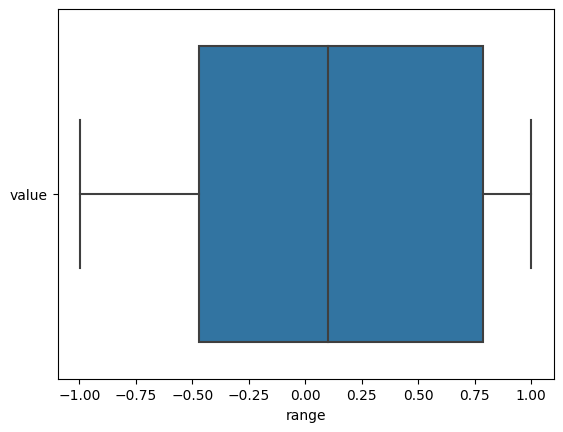

In [19]:
sns.boxplot(data=y_train, orient="h").set(xlabel= 'range')
plt.show()

There is no outlier anymore. The box plot much well defined now.

### Correlation Analysis

In [20]:
#Perform correlation analysis between numerical features
corr_mat = Train_data.corr(method ='pearson') #Pearson correlation is used
corr_mat

,time-stamp,value
time-stamp,1.000000,-0.180103
value,-0.180103,1.000000


There seems no correlation between the time-stamp and the value.

### Visualizations

Since the feature is just a time-stamp, visualizing it alone does not give us any new information. Let us visualize the two together.

[]

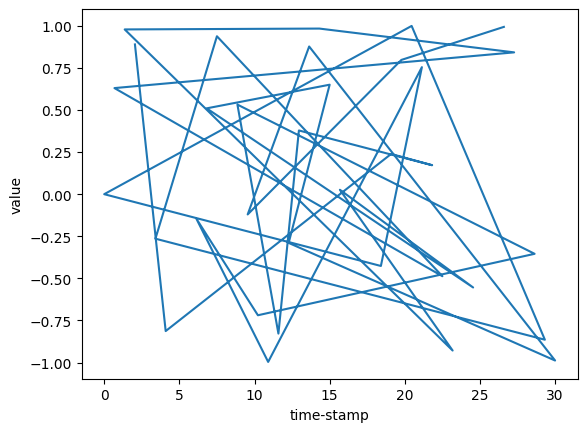

In [21]:
plt.plot(X_train, y_train)
plt.xlabel("time-stamp")
plt.ylabel("value")
plt.plot()

This does not convey any relevant information.

Since this is a time-based data, one may get some intuitions after sorting it in the order of increasing time and then visualizing it.

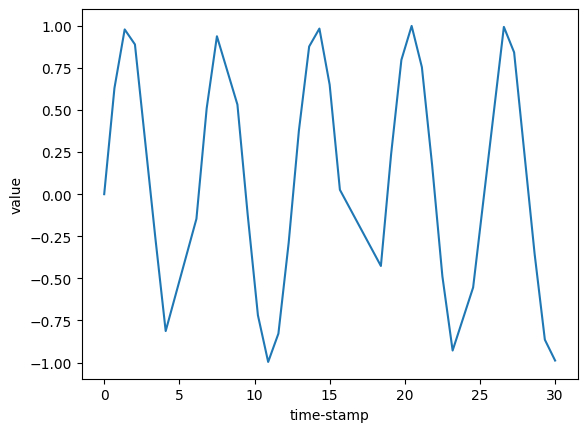

In [22]:
#Sort
Sorted_data = Train_data
Sorted_data.sort_values('time-stamp', inplace=True)

#Visualize
plt.plot(Sorted_data['time-stamp'], Sorted_data['value'])
plt.xlabel("time-stamp")
plt.ylabel("value")
plt.show()

This seems similar to a sine wave.

#6.   Model Building: Training and Testing



Before jumping to the Kernel ridge regression, let us first try to build intuition on why simple ridge regression will not work for this case.

In [23]:
#Import ridge regression class
from sklearn.linear_model import Ridge #Simple Ridge Regression: Linear least squares with l2 regularization.
model = Ridge(alpha=1.0)

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set

In [24]:
# Evaluate the model using commonly used metrics
from sklearn.metrics import r2_score
r2_train = r2_score(y_train, y_pred_train)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics on train data
print("Train R-squared score: ", r2_train)
print("Test R-squared score: ", r2)

Train R-squared score:  0.03243711772671665
Test R-squared score:  -0.06908327788031143


This is a very bad result. The model has not trained at all.

A funciton identical to sine wave cannot be fitted by a linear line in its original form. Thus, we shift to kernel methods.


We will use the Kernel ridge regression (KRR) class that combines ridge regression (linear least squares with l2-norm regularization) with the kernel trick, particularly the radial basis function (RBF) kernel.

In [25]:
#Import Ridge Kernel Regression class
from sklearn.kernel_ridge import KernelRidge
model = KernelRidge(kernel="rbf") #Radial basis function kernel

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set

# 7. Results and Interpretation

In [26]:
# Evaluate the model using commonly used metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Print the evaluation metrics on train data
print("Evaluation metrics: Train Data")
print("Mean absolute error: ", mae_train)
print("Mean squared error: ", mse_train)
print("R-squared score: ", r2_train)

Evaluation metrics: Train Data
Mean absolute error:  0.23492574667793442
Mean squared error:  0.06803844640255145
R-squared score:  0.8554256898556578


We are able to built a Kernel ridge regression model that predicts the target variable with an R2 score of 0.85 on train data.

Below, let us check the evaluation metrics of the test data.

In [27]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


# Print the evaluation metrics on test data
print("Evaluation metrics: Test Data")
print("Mean absolute error: ", mae)
print("Mean squared error: ", mse)
print("R-squared score: ", r2)

Evaluation metrics: Test Data
Mean absolute error:  0.44458276214879455
Mean squared error:  0.2361742814238229
R-squared score:  0.497996788505944


This is not a very good result. Let us try to improve it through hyperparameter tuning.

### Hyperparameter Tuning: Grid Search

Kernel Ridge Regression has two important hyperparameters:


1.   **Alpha**: Strength of regularization. Must be a positive float value. Larger values specify stronger regularization.
2.   **Gamma**: Smoothning parameter. Determines how strongly each training example influences the classification of points that are far away from it. Small gamma value results in a smoother decision surface, while a large gamma value results in a more complex decision surface that is more tightly fitted to the training data.



**Grid search** is a process that searches exhaustively through a manually specified subset of the hyperparameter space of the targeted algorithm.

We will use Grid Search for estimating the Kernel Ridge Regression hyperparameters.

In [28]:
# Hyperparameter tuning
alpha_values = [0.1, 1, 10, 100]
gamma_values = [0.01, 0.1, 1, 10]
model_best = KernelRidge(kernel="rbf")


# Tune the hyperparameters using the R2 score on the testing set
alpha_best = None
gamma_best = None
best_r2 = -np.inf
for alpha in alpha_values:
    for gamma in gamma_values:
        model_best.set_params(alpha=alpha, gamma=gamma)
        model_best.fit(X_train, y_train)
        y_pred = model_best.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        if r2 > best_r2:
            best_r2 = r2
            alpha_best = alpha
            gamma_best = gamma

# Fit the Kernel Ridge regression model with the best hyperparameters and evaluate it
model_best.set_params(alpha=alpha_best, gamma=gamma_best)
model_best.fit(X_train, y_train)
y_train_pred_best = model_best.predict(X_train)
y_test_pred_best = model_best.predict(X_test)
r2_best_train = r2_score(y_train, y_train_pred_best)
r2_best_test = r2_score(y_test, y_test_pred_best)
print("Best alpha: ", alpha_best)
print("Best gamma: ", gamma_best)
print('Train R2 score: ', r2_best_train)
print("Test R2 score: ",r2_best_test)

Best alpha:  0.1
Best gamma:  0.1
Train R2 score:  0.9603579700278589
Test R2 score:  0.9064481706647295


The hyperparameter tuning has significantly improved the model performance.

This also reflects the downside of this method that it is severly affected by the choices of the hyperparameters.

### Polynomial Kernel Regression (Example)

In [29]:
# Pipeline function provides a framework for building and evaluating ML pipelines viz., a sequence of data preprocessing steps and machine learning models that are executed in a specific order
from sklearn.pipeline import Pipeline

#PolynomialFeatures function generates new set of polynomial and interaction features using the existing features
#E.g., for a 2D input sample of the form [a,b], the second degree polynomial features are [1, a, b, a^2, b^2, ab]
from sklearn.preprocessing import PolynomialFeatures

#LinearRegression class provides the functionality of the Ordinary least squares Linear Regression model
from sklearn.linear_model import LinearRegression

In [30]:
#Generate Random Data for Polynomial Regression
np.random.seed(0)
n_samples = 45
X = np.sort(np.random.rand(n_samples))
y = np.sin(2*np.pi*X) + np.random.randn(n_samples) * 0.2

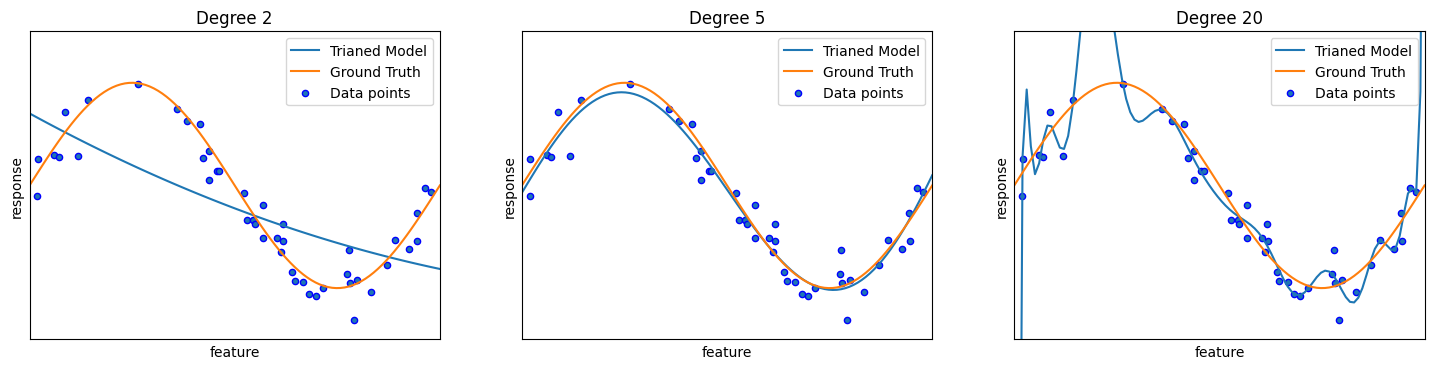

In [31]:
degrees = [2, 5, 20]  # selecting different degree of polynomials

plt.figure(figsize=(18, 4))
for i, degree in enumerate(degrees):
    ax = plt.subplot(1, len(degrees), i+1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Trianed Model")
    plt.plot(X_test, np.sin(2*np.pi*X_test), label="Ground Truth")
    plt.scatter(X, y, edgecolor='b', s=20, label="Data points")
    plt.xlabel("feature")
    plt.ylabel("response")
    plt.xlim((0, 1))
    plt.ylim((-1.5, 1.5))
    plt.legend(loc="best")
    plt.title(f"Degree {degree}")
plt.show()



*   Degree 1: Underfitting
*   Degree 5: Optimal fit
*   Degree 20: Overfitting



# 8. Conclusion

We have built a Kernel regression model that learns the pattern of the enemy signal a train R2 score of approx. 0.96 and a test R2 score of 0.90.

The best value of the both the hyperparameters, alpha and gamma, turns out to be 0.1.

# 9.   Try it yourself excercise



*   **Problem Statement**: Using Kernel regression, predict the concrete compressive strength based on available relevant data.
*   **Task**: The concrete compressive strength is a highly nonlinear function of age and ingredients. The idea is to apply kernel regression to this problem. The target variable is 'Concrete compressive strength'.
*   More information is available here: https://archive.ics.uci.edu/ml/datasets/Concrete+Compressive+Strength


In [32]:
# Load the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls'
data = pd.read_excel(url)
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


# 10. Summary

In this module, we learned

*   To apply a **Kernel Ridge Regression** model to a dataset
*   To handle **outlier** in the data
*   To perform hyperparameter tuning using **Grid Search**
*   To excute **Polynomial Kernel Regression**
*   To visualize **Underfitted** and **Overfitted** models